<a href="https://colab.research.google.com/github/yuvrajsharmaaa/DL-LAb/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Feature Extraction with a Single Perceptron-like Neuron

A simple 'neuron' often refers to a perceptron or a logistic regression unit. It takes multiple inputs (features), multiplies each input by a corresponding weight, sums these weighted inputs, adds a bias, and then applies an activation function to produce an output.

In this context, **feature extraction** isn't about transforming raw data into entirely new, more complex features (like PCA or autoencoders). Instead, the neuron's learned weights highlight which of the *given* input features are most important or contribute most significantly to its decision-making process. Features with larger absolute weights are considered more 'extracted' or impactful by that specific neuron.

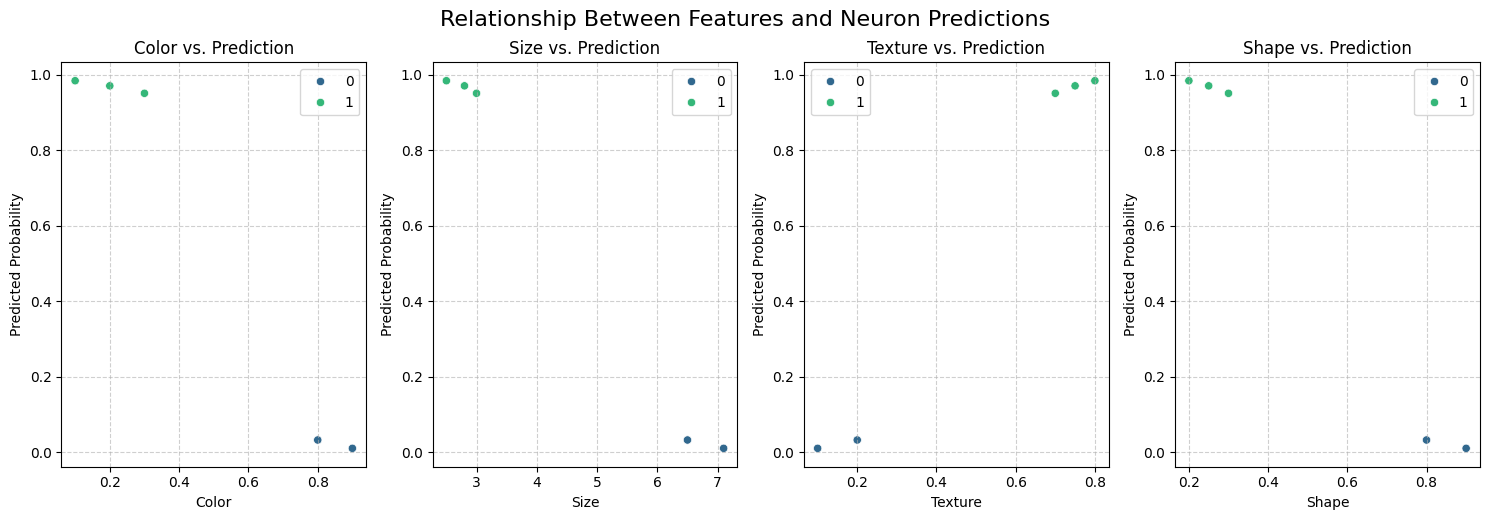

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X, predictions, and neuron are available from previous cells
feature_names = ['Color', 'Size', 'Texture', 'Shape']

plt.figure(figsize=(15, 5))

for i in range(X.shape[1]):
    plt.subplot(1, X.shape[1], i + 1)
    sns.scatterplot(x=X[:, i], y=predictions, hue=y, palette='viridis', legend='full')
    plt.title(f'{feature_names[i]} vs. Prediction')
    plt.xlabel(feature_names[i])
    plt.ylabel('Predicted Probability')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.suptitle('Relationship Between Features and Neuron Predictions', y=1.03, fontsize=16)
plt.show()

From these plots, you can observe the trends that the neuron has learned:

*   **Positive Relationship:** If the predicted probability generally increases as a feature's value increases, it indicates a positive weight for that feature (e.g., higher values of 'color' leading to higher probabilities).
*   **Negative Relationship:** If the predicted probability generally decreases as a feature's value increases, it indicates a negative weight for that feature (e.g., higher values of 'texture' leading to lower probabilities).
*   **Weak Relationship:** If the predicted probability shows little to no consistent change as a feature's value changes, it suggests a weight close to zero, meaning that feature has less influence on the neuron's decision.

In [ ]:
import numpy as np

# Let's create some synthetic data
# Each row is a sample, each column is a feature
# Example features: [color (0-1), size (0-10), texture (0-1), shape (0-1)]
X = np.array([
    [0.1, 2.5, 0.8, 0.2], # Sample 1
    [0.9, 7.1, 0.1, 0.9], # Sample 2
    [0.3, 3.0, 0.7, 0.3], # Sample 3
    [0.8, 6.5, 0.2, 0.8], # Sample 4
    [0.2, 2.8, 0.75, 0.25] # Sample 5
])

# Let's assume a 'target' output for these samples (e.g., is_positive_category)
y = np.array([1, 0, 1, 0, 1]) # Binary classification

print("Input Features (X):")
print(X)
print("\nTarget Labels (y):")
print(y)

Input Features (X):
[[0.1  2.5  0.8  0.2 ]
 [0.9  7.1  0.1  0.9 ]
 [0.3  3.   0.7  0.3 ]
 [0.8  6.5  0.2  0.8 ]
 [0.2  2.8  0.75 0.25]]

Target Labels (y):
[1 0 1 0 1]


In [ ]:
class SingleNeuron:
    def __init__(self, num_features):
        # Initialize weights randomly, and bias to 0
        self.weights = np.random.randn(num_features) * 0.01
        self.bias = 0.0

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def predict(self, X):
        # Weighted sum of inputs + bias
        linear_output = np.dot(X, self.weights) + self.bias
        # Apply activation function
        y_predicted = self.sigmoid(linear_output)
        return y_predicted

    def train(self, X, y, learning_rate=0.1, num_epochs=1000):
        num_samples = X.shape[0]

        for epoch in range(num_epochs):
            # Make predictions
            y_predicted = self.predict(X)

            # Calculate the error
            error = y_predicted - y

            # Calculate gradients
            # dL/dw = (y_pred - y) * sigmoid'(linear_output) * X
            # For sigmoid: sigmoid'(z) = sigmoid(z) * (1 - sigmoid(z))
            # We can simplify gradient calculation for binary cross-entropy loss
            # with sigmoid output to (y_pred - y) * X

            # Reshape X for broadcasting if needed (num_samples, num_features)
            dw = np.dot(X.T, error) / num_samples
            db = np.sum(error) / num_samples

            # Update weights and bias
            self.weights -= learning_rate * dw
            self.bias -= learning_rate * db

            if epoch % 200 == 0:
                loss = -np.mean(y * np.log(y_predicted + 1e-9) + (1 - y) * np.log(1 - y_predicted + 1e-9))
                print(f"Epoch {epoch}: Loss = {loss:.4f}")


num_features = X.shape[1]
neuron = SingleNeuron(num_features)

print("Initial Weights:", neuron.weights)
print("Initial Bias:", neuron.bias)

# Train the neuron
neuron.train(X, y)

print("\nLearned Weights:", neuron.weights)
print("Learned Bias:", neuron.bias)

# Make predictions with the trained neuron
predictions = neuron.predict(X)
print("\nPredictions (raw probabilities):")
print(predictions)

# Convert probabilities to binary predictions
binary_predictions = (predictions > 0.5).astype(int)
print("Binary Predictions:")
print(binary_predictions)

# Evaluate accuracy
accuracy = np.mean(binary_predictions == y)
print(f"Accuracy: {accuracy * 100:.2f}%")

Initial Weights: [ 0.00366911 -0.00439342 -0.00616156  0.00217257]
Initial Bias: 0.0
Epoch 0: Loss = 0.6927
Epoch 200: Loss = 0.1320
Epoch 400: Loss = 0.0687
Epoch 600: Loss = 0.0461
Epoch 800: Loss = 0.0347

Learned Weights: [-0.94818858 -0.98704094  4.17843194 -0.69038806]
Learned Bias: 3.492032874351991

Predictions (raw probabilities):
[0.98423821 0.01022306 0.95093218 0.0323296  0.97068514]
Binary Predictions:
[1 0 1 0 1]
Accuracy: 100.00%


### Testing the Trained Neuron on New, Unseen Data

Now, let's create a new set of data points to evaluate the trained neuron's ability to generalize to inputs it hasn't seen during its training phase.

### Interpreting the Learned Weights as Feature Extraction

After training, observe the `Learned Weights` array. Each weight corresponds to an input feature:

*   `weights[0]` corresponds to `color`
*   `weights[1]` corresponds to `size`
*   `weights[2]` corresponds to `texture`
*   `weights[3]` corresponds to `shape`

**How do these weights represent feature extraction?**

*   **Magnitude:** Features with larger absolute weights have a stronger influence on the neuron's output. A large positive weight means that increasing that feature's value strongly increases the likelihood of a positive output (closer to 1). A large negative weight means increasing that feature's value strongly decreases the likelihood of a positive output.

*   **Sign:** The sign indicates the direction of the influence. Positive weights contribute positively to the output (making it more likely to be 1), while negative weights contribute negatively (making it more likely to be 0).

In our synthetic example, if, for instance, `weights[1]` (for 'size') is significantly larger than others, the neuron has 'extracted' 'size' as a very important feature for distinguishing between the two classes. If `weights[2]` (for 'texture') is close to zero, it means 'texture' is not considered a very useful feature by this particular neuron for this task.

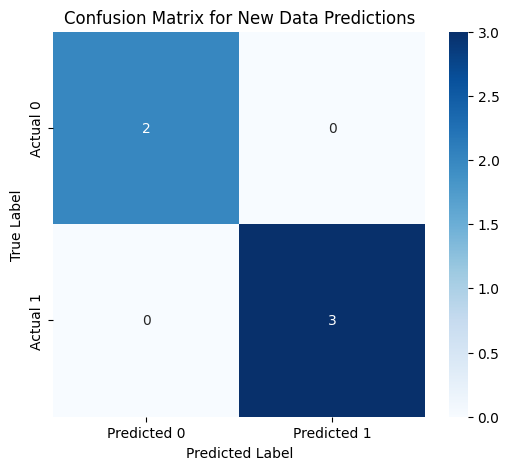


Accuracy on new data: 100.00%

Classification Report on new data:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure binary_predictions_new and y_new are available from previous cells

# Generate Confusion Matrix
cm = confusion_matrix(y_new, binary_predictions_new)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for New Data Predictions')
plt.show()

# Calculate Accuracy
accuracy = accuracy_score(y_new, binary_predictions_new)
print(f"\nAccuracy on new data: {accuracy * 100:.2f}%")

# Display Classification Report
print("\nClassification Report on new data:")
print(classification_report(y_new, binary_predictions_new))

In [ ]:
import numpy as np

# Create new synthetic data for testing
# Ensure the structure (number of features) matches the training data
X_new = np.array([
    [0.05, 1.0, 0.9, 0.1], # Expected: 1
    [0.95, 8.0, 0.05, 0.95], # Expected: 0
    [0.2, 2.0, 0.7, 0.25], # Expected: 1
    [0.85, 7.5, 0.15, 0.8], # Expected: 0
    [0.1, 1.5, 0.85, 0.15]  # Expected: 1
])
y_new = np.array([1, 0, 1, 0, 1]) # True labels for the new data

print("New Input Features (X_new):")
print(X_new)
print("\nNew True Labels (y_new):")
print(y_new)

# Make predictions with the trained neuron on the new data
predictions_new = neuron.predict(X_new)
print("\nPredictions on new data (raw probabilities):")
print(predictions_new)

# Convert probabilities to binary predictions
binary_predictions_new = (predictions_new > 0.5).astype(int)
print("Binary Predictions on new data:")
print(binary_predictions_new)

# Evaluate accuracy on the new data
accuracy_new = np.mean(binary_predictions_new == y_new)
print(f"\nAccuracy on new data: {accuracy_new * 100:.2f}%")

New Input Features (X_new):
[[0.05 1.   0.9  0.1 ]
 [0.95 8.   0.05 0.95]
 [0.2  2.   0.7  0.25]
 [0.85 7.5  0.15 0.8 ]
 [0.1  1.5  0.85 0.15]]

New True Labels (y_new):
[1 0 1 0 1]

Predictions on new data (raw probabilities):
[0.99786922 0.0031663  0.98338376 0.00954374 0.99534321]
Binary Predictions on new data:
[1 0 1 0 1]

Accuracy on new data: 100.00%
